Поскольку исходники датасетов с моей работы находятся под NDA данный EDA проведён на синтетических данных и не является источником инсайдерской информации.


**Выводы по реальным данным:Выводы на основании реальных данных - в отличие от синтетики качество данных в ряде показателей не является удовлетворительным, уточнение ряда булевых признаков при их расхождении, точная классификация ролей и обоснованность алгоритмически выевляемых расхождений требует анализа введённого людьми текста.Классификация ряда применяющихся типов не очевидна, часто имеются синонимичные по общему смыслу типы с разными классами в системе. Консультация с доступными экспертами ситуацию не прояснил - типы сложились в ходе особенностей практического применения. В ряде процедур отсутствует однозначная связь между конкретной заявкой и итоговым документом, что требует анализа текста 1-4 заявок.Часто в разных системах для обозначения одного и того же используются разные варинты написания, что усложняет сверку алгоритмами, однако при помощи алгоритмических методов можно значительно сократить колличество анализируемых строк (в конкретном примере ппереписанных в процессе условий получилось снизить колличество случаев с тысяч до около двух сотен)**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')



df_contracts = pd.read_csv(pth + 'contracts.csv', parse_dates=['дата_создания', 'дата_подписания', 'дата_исполнения', 'дата_расторжения'])
df_counterparties = pd.read_csv(pth + 'counterparties.csv')
df_contacts = pd.read_csv(pth + 'counterparty_contacts.csv')
df_restrictions = pd.read_csv(pth + 'contract_restrictions.csv', parse_dates=['дата_начала', 'дата_окончания'])
df_payments = pd.read_csv(pth + 'payment_history.csv', parse_dates=['дата_выплаты'])
df_approvals = pd.read_csv(pth + 'approvals.csv', parse_dates=['дата_согласования'])
df_items = pd.read_csv(pth + 'contract_items.csv')
df_milestones = pd.read_csv(pth + 'contract_milestones.csv', parse_dates=['плановая_дата', 'фактическая_дата'])
df_add_agreements = pd.read_csv(pth + 'additional_agreements.csv', parse_dates=['дата'])
df_files = pd.read_csv(pth + 'contract_files.csv', parse_dates=['дата_загрузки'])
df_amendments = pd.read_csv(pth + 'contract_amendments.csv', parse_dates=['дата_изменения'])
df_acts = pd.read_csv(pth + 'acceptance_acts.csv', parse_dates=['дата_акта'])
df_disputes = pd.read_csv(pth + 'disputes.csv', parse_dates=['дата_возникновения', 'дата_решения'])
df_limit_exceptions = pd.read_csv(pth + 'contract_limit_exceptions.csv', parse_dates=['дата_фиксации'])
df_splits = pd.read_csv(pth + 'contract_splits.csv')

for name, df in [('contracts', df_contracts), ('counterparties', df_counterparties),
                 ('restrictions', df_restrictions), ('payments', df_payments),
                 ('approvals', df_approvals), ('limit_exceptions', df_limit_exceptions),
                 ('splits', df_splits)]:
    print(f"{name}: {df.shape}")

contracts: (6437, 35)
counterparties: (231, 12)
restrictions: (492, 10)
payments: (19311, 9)
approvals: (38622, 10)
limit_exceptions: (277, 9)
splits: (644, 6)


In [5]:
df_contracts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6437 entries, 0 to 6436
Data columns (total 35 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   id_договора                          6437 non-null   int64         
 1   вид_договора                         6437 non-null   object        
 2   наименование                         6437 non-null   object        
 3   сумма                                6437 non-null   float64       
 4   валюта                               6437 non-null   object        
 5   сумма_в_рублях                       6437 non-null   float64       
 6   ставка_ндс                           6437 non-null   int64         
 7   тип_цены                             6437 non-null   object        
 8   дата_создания                        6437 non-null   datetime64[ns]
 9   дата_подписания                      5760 non-null   datetime64[ns]
 10  должность_по

In [6]:
df_contracts['статус'].value_counts()

статус
Исполнен      2591
Подписан      2518
Черновик       677
Расторгнут     651
Name: count, dtype: int64

In [7]:
df_contracts['валюта'].value_counts()

валюта
RUB    4020
BYN     808
KZT     806
CNY     394
USD     211
EUR     198
Name: count, dtype: int64

In [8]:
df_contracts.describe(include='all')

,id_договора,вид_договора,наименование,сумма,валюта,сумма_в_рублях,ставка_ндс,тип_цены,дата_создания,дата_подписания,...,форс_мажор,порядок_разрешения_споров,конфиденциальность,применимое_право,срок_уведомления_о_расторжении_дней,гарантийный_срок_мес,наличие_лицензий_у_контрагента,архивный,parent_договор_id,причина_разбиения
count,6437.000000,6437,6437,6.437000e+03,6437,6.437000e+03,6437.000000,6437,6437,5760,...,6437,6437,6437,6437,6437.000000,6437.000000,6437,6437,644.000000,644
unique,NaN,5,6437,NaN,6,NaN,NaN,2,NaN,NaN,...,2,3,2,4,NaN,NaN,2,2,NaN,4
top,NaN,Поставка,Услуги №6437 от 10.02.2026,NaN,RUB,NaN,NaN,С НДС,NaN,NaN,...,Да,Суд по месту нахождения ответчика,Нет,КНР,NaN,NaN,True,True,NaN,Обход лимита суммы
freq,NaN,1353,1,NaN,4020,NaN,NaN,5152,NaN,NaN,...,3235,2166,3246,1655,NaN,NaN,3226,3245,NaN,177
mean,3219.000000,NaN,NaN,4.914401e+06,NaN,3.645646e+07,15.055150,NaN,2024-08-24 14:09:51.704210176,2024-09-06 07:39:29.999999744,...,NaN,NaN,NaN,NaN,50.311791,7.432034,NaN,NaN,1625.366460,NaN
min,1.000000,NaN,NaN,1.699410e+03,NaN,6.458000e+01,0.000000,NaN,2023-02-28 00:00:00,2023-03-02 00:00:00,...,NaN,NaN,NaN,NaN,10.000000,0.000000,NaN,NaN,1.000000,NaN
25%,1610.000000,NaN,NaN,2.455364e+06,NaN,9.904370e+05,10.000000,NaN,2023-11-25 00:00:00,2023-12-06 00:00:00,...,NaN,NaN,NaN,NaN,30.000000,0.000000,NaN,NaN,429.250000,NaN
50%,3219.000000,NaN,NaN,4.840494e+06,NaN,4.642133e+06,20.000000,NaN,2024-08-22 00:00:00,2024-09-02 00:00:00,...,NaN,NaN,NaN,NaN,50.000000,0.000000,NaN,NaN,1254.500000,NaN
75%,4828.000000,NaN,NaN,7.383226e+06,NaN,8.568522e+06,20.000000,NaN,2025-05-25 00:00:00,2025-06-06 00:00:00,...,NaN,NaN,NaN,NaN,71.000000,14.000000,NaN,NaN,2465.250000,NaN
max,6437.000000,NaN,NaN,9.999688e+06,NaN,9.641377e+08,20.000000,NaN,2026-02-27 00:00:00,2026-03-28 00:00:00,...,NaN,NaN,NaN,NaN,90.000000,36.000000,NaN,NaN,6067.000000,NaN


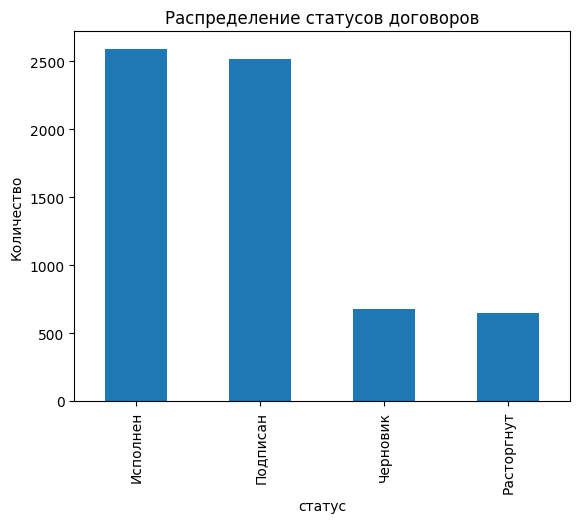

In [9]:
df_contracts['статус'].value_counts().plot(kind='bar')
plt.title('Распределение статусов договоров')
plt.ylabel('Количество')

plt.show()

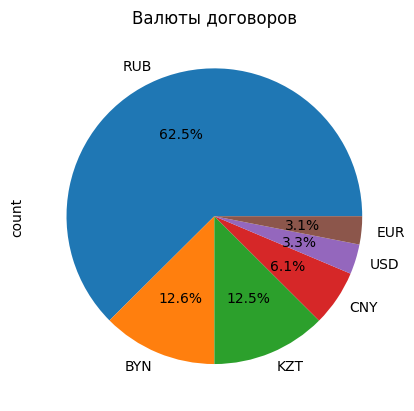

In [10]:
df_contracts['валюта'].value_counts().plot(kind='pie', autopct='%1.1f%%', title='Валюты договоров')
plt.show()

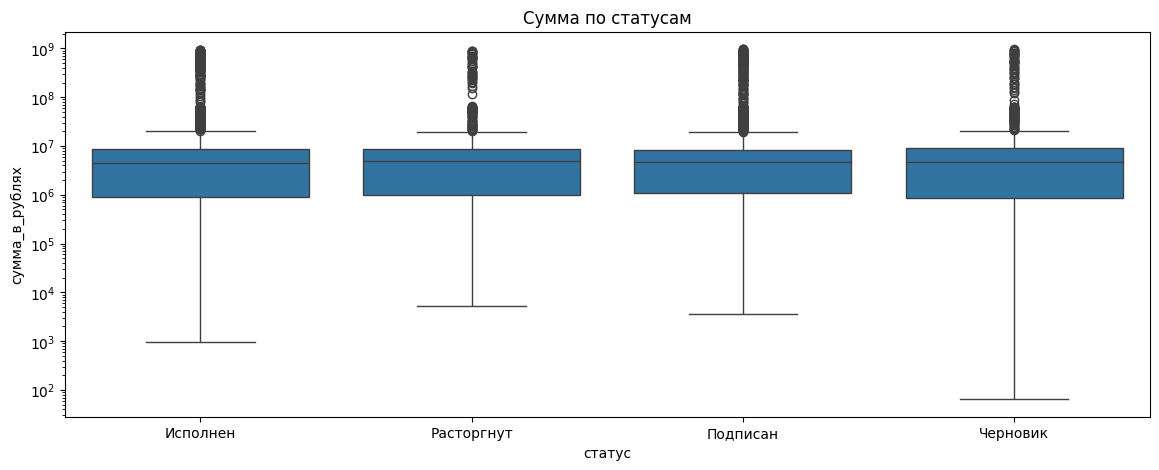

In [11]:
plt.figure(figsize=(14,5))
sns.boxplot(x='статус', y='сумма_в_рублях', data=df_contracts)
plt.title('Сумма по статусам')
plt.yscale('log')
plt.show()

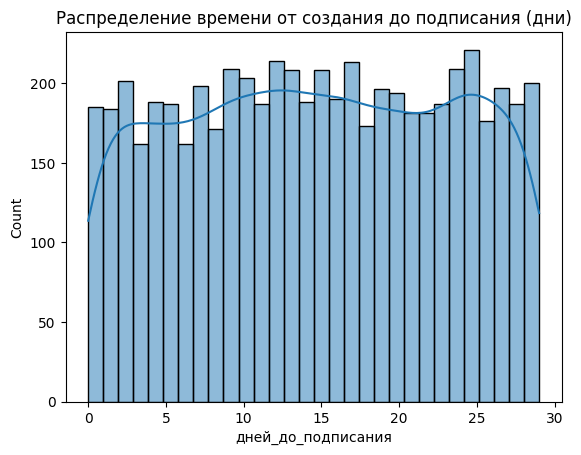

In [12]:
signed = df_contracts[df_contracts['статус']!='Черновик'].copy()
signed['дней_до_подписания'] = (signed['дата_подписания'] - signed['дата_создания']).dt.days
sns.histplot(signed['дней_до_подписания'], bins=30, kde=True)
plt.title('Распределение времени от создания до подписания (дни)')
plt.show()

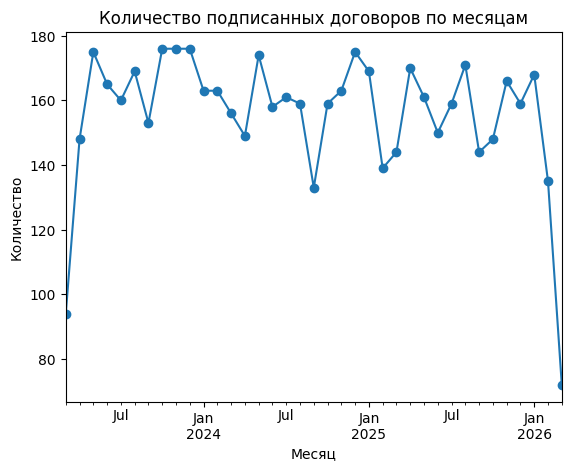

In [13]:
df_contracts['месяц_подписания'] = df_contracts['дата_подписания'].dt.to_period('M')
monthly = df_contracts[df_contracts['статус']!='Черновик'].groupby('месяц_подписания').size()
monthly.plot(kind='line', marker='o', title='Количество подписанных договоров по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Количество')
plt.show()

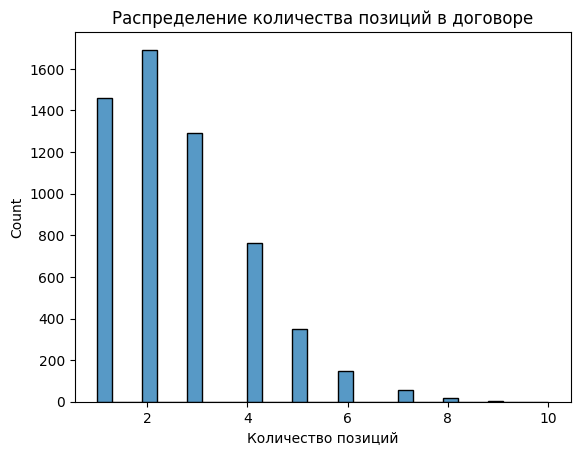

('Среднее число позиций:', np.float64(2.5924645696508812))

In [14]:
items_per_contract = df_items.groupby('id_договора').size()
sns.histplot(items_per_contract, bins=30, kde=False)
plt.title('Распределение количества позиций в договоре')
plt.xlabel('Количество позиций')
plt.show()
"Среднее число позиций:",items_per_contract.mean()

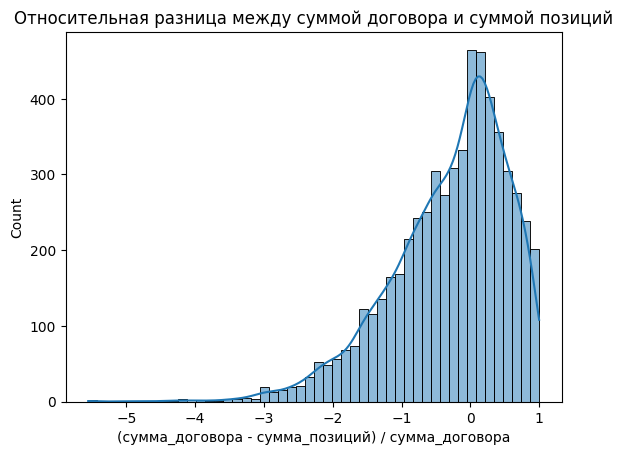

In [15]:
item_sum = df_items.groupby('id_договора')['сумма_в_рублях'].sum().reset_index()
item_sum.columns = ['id_договора', 'сумма_позиций']
merged = pd.merge(df_contracts[['id_договора', 'сумма_в_рублях']], item_sum, on='id_договора')
merged['разница'] = merged['сумма_в_рублях'] - merged['сумма_позиций']
merged['разница_отн'] = merged['разница'] / merged['сумма_в_рублях']
sns.histplot(merged['разница_отн'], bins=50, kde=True)
plt.title('Относительная разница между суммой договора и суммой позиций')
plt.xlabel('(сумма_договора - сумма_позиций) / сумма_договора')
plt.show()

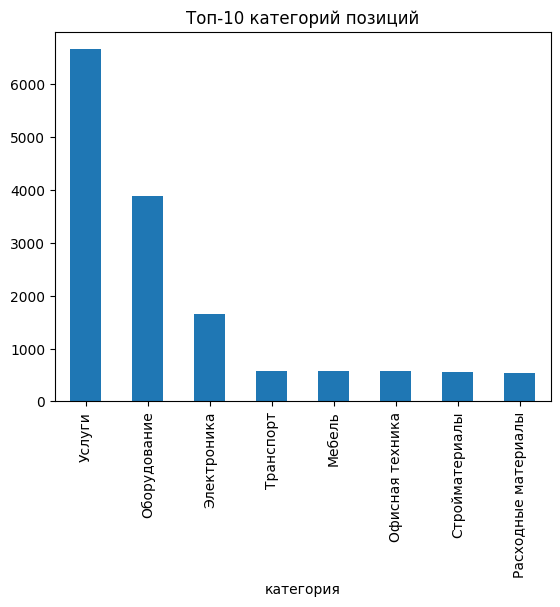

In [16]:
df_items['категория'].value_counts().head(10).plot(kind='bar', title='Топ-10 категорий позиций')
plt.show()

In [17]:
df_restrictions['тип_ограничения'].value_counts()

тип_ограничения
Только в рублях                130
Лимит суммы                    128
Запрет на вид договора         126
Требуется доп. согласование    108
Name: count, dtype: int64

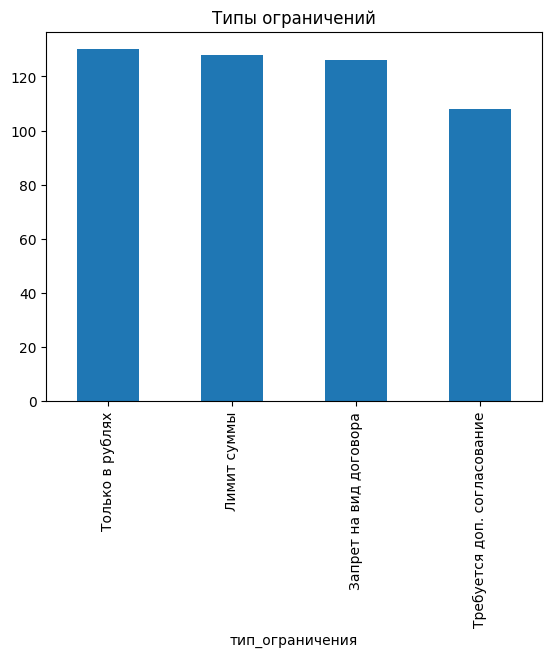

In [18]:
df_restrictions['тип_ограничения'].value_counts().plot(kind='bar', title='Типы ограничений')
plt.show()

In [19]:
df_restrictions['severity'].value_counts()

severity
Мягкое     168
Жёсткое    165
Среднее    159
Name: count, dtype: int64

In [20]:
#Требуют особого согласования
df_restrictions['requires_override_approval'].mean()*100

np.float64(53.45528455284553)

In [21]:
today = datetime.now().date()
active_restrictions = df_restrictions[
    (df_restrictions['дата_начала'] <= pd.Timestamp(today)) & 
    (df_restrictions['дата_окончания'] >= pd.Timestamp(today)) &
    (df_restrictions['активно'] == True)
]
"Активных ограничений:", len(active_restrictions)

('Активных ограничений:', 89)

In [22]:
#Исключения
print("Всего зафиксировано исключений:", len(df_limit_exceptions))
#Статусы исключений
df_limit_exceptions['статус'].value_counts()

Всего зафиксировано исключений: 277


статус
Отказано                  95
Согласовано               91
Требуется согласование    91
Name: count, dtype: int64

In [23]:
#Распределение типов нарушений
df_limit_exceptions['тип_нарушения'].value_counts()

тип_нарушения
Превышение лимита суммы    277
Name: count, dtype: int64

In [24]:
# Суммы превышений
df_limit_exceptions['сумма_превышения'] = pd.to_numeric(df_limit_exceptions['сумма_превышения'], errors='coerce')
df_limit_exceptions['сумма_превышения'].describe()

count    2.770000e+02
mean     4.507908e+06
std      2.740335e+06
min      4.444270e+03
25%      2.053269e+06
50%      4.461144e+06
75%      6.824199e+06
max      9.583971e+06
Name: сумма_превышения, dtype: float64

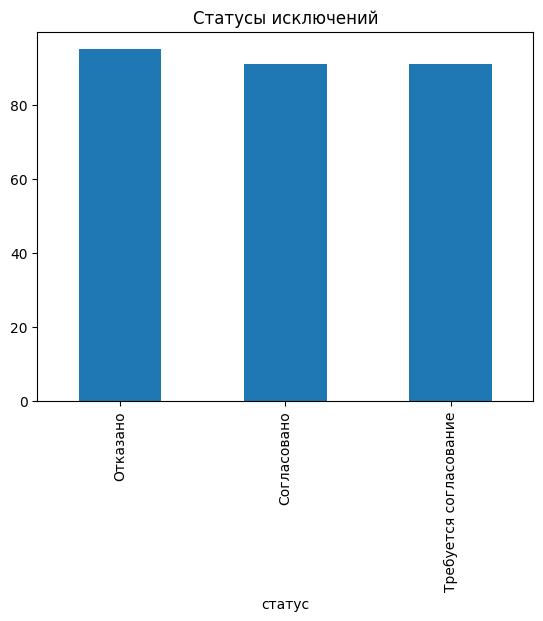

In [25]:
df_limit_exceptions['статус'].value_counts().plot(kind='bar')
plt.title('Статусы исключений')
plt.show()

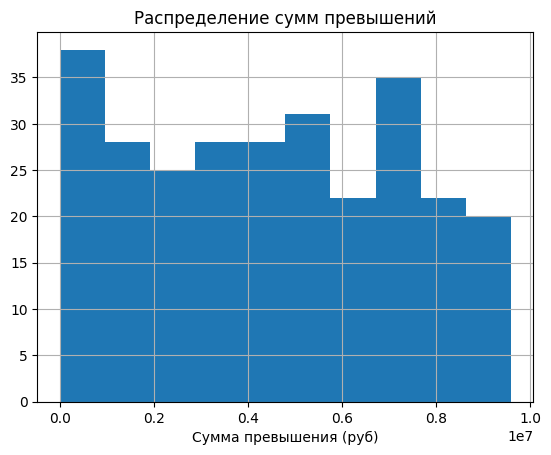

In [26]:
df_limit_exceptions['сумма_превышения'].hist()
plt.title('Распределение сумм превышений')
plt.xlabel('Сумма превышения (руб)')
plt.show()

In [27]:
#Согласования и потенциальные исключения
print("Согласований:", len(df_approvals))
#Статусы
df_approvals['статус'].value_counts()

Согласований: 38622


статус
Согласовано        26966
На рассмотрении     7730
Отказано            3926
Name: count, dtype: int64

In [28]:
#Типы согласований
df_approvals['тип_согласования'].value_counts()

тип_согласования
Обычное           38068
Коллегиальное       191
Экстренное          189
Особое (лимит)      174
Name: count, dtype: int64

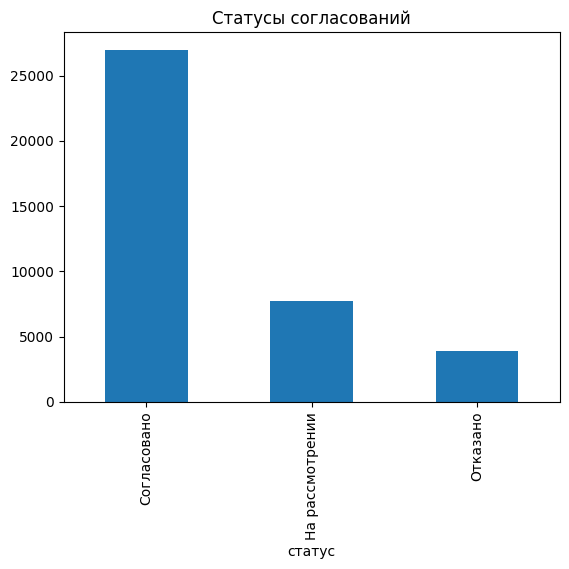

In [29]:
df_approvals['статус'].value_counts().plot(kind='bar', title='Статусы согласований')
plt.show()

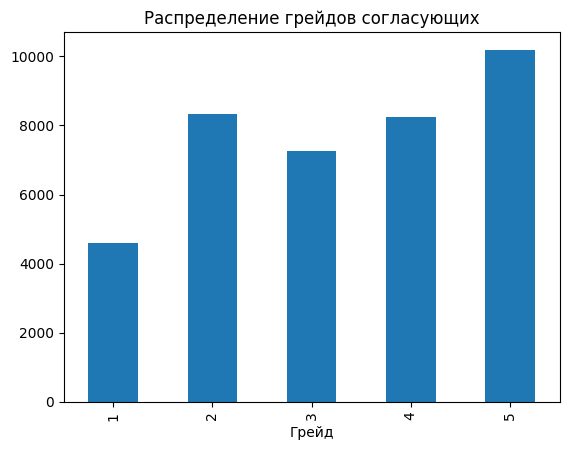

In [30]:
df_approvals['грейд'].value_counts().sort_index().plot(kind='bar', title='Распределение грейдов согласующих')
plt.xlabel('Грейд')
plt.show()

In [31]:
#Согласования связанные с исключениями
df_approvals['id_исключения'].notna().sum()/len(df_approvals)*100

np.float64(1.4344156180415308)

In [32]:
#Анализ выплат
payments_sum = df_payments.groupby('id_договора')['сумма_в_рублях'].sum().reset_index()
payments_sum.columns = ['id_договора', 'выплачено_всего']
df_contracts_with_payments = df_contracts.merge(payments_sum, on='id_договора', how='left')
df_contracts_with_payments['выплачено_всего'] = df_contracts_with_payments['выплачено_всего'].fillna(0)

In [33]:
# Доля выплат от суммы договора
df_contracts_with_payments['доля_выплат'] = df_contracts_with_payments['выплачено_всего'] / df_contracts_with_payments['сумма_в_рублях']
valid = df_contracts_with_payments[df_contracts_with_payments['сумма_в_рублях'] > 0]
valid['доля_выплат'].describe()

count    6437.000000
mean        0.769873
std         0.507890
min         0.000000
25%         0.397245
50%         0.702427
75%         1.084862
max         3.125329
Name: доля_выплат, dtype: float64

In [34]:
# Договоры с превышением выплат над суммой
len(valid['доля_выплат'] > 1), len(valid['доля_выплат'] > 1)/len(valid)*100

(6437, 100.0)

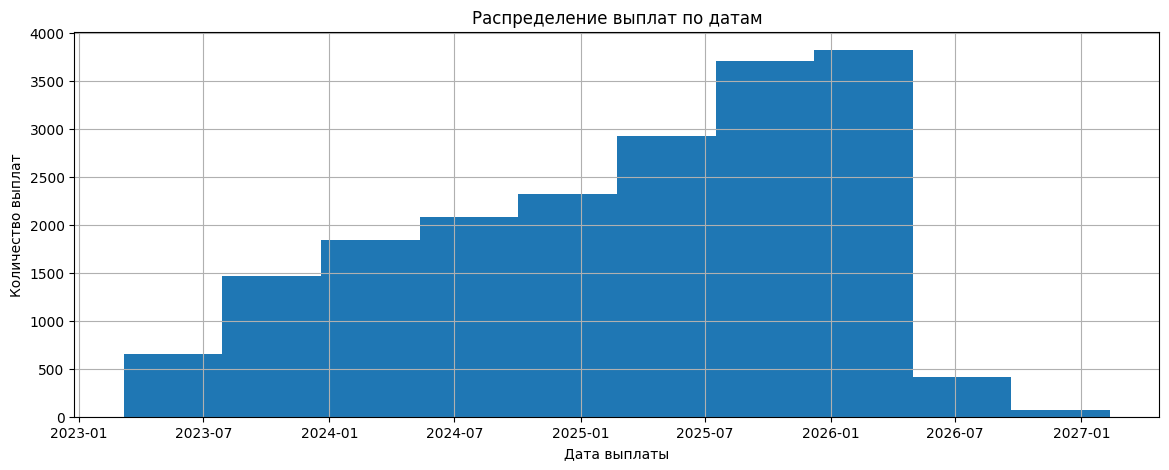

In [35]:
plt.figure(figsize=(14,5))
df_payments['дата_выплаты'].hist()
plt.title('Распределение выплат по датам')
plt.xlabel('Дата выплаты')
plt.ylabel('Количество выплат')
plt.show()

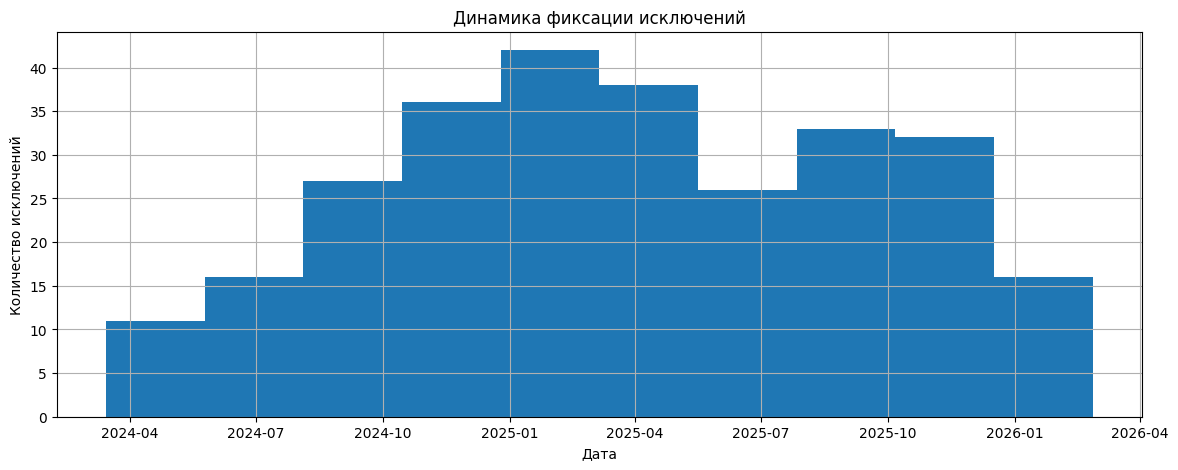

In [36]:
plt.figure(figsize=(14,5))
df_limit_exceptions['дата_фиксации'].hist()
plt.title('Динамика фиксации исключений')
plt.xlabel('Дата')
plt.ylabel('Количество исключений')
plt.show()

In [37]:
# Определим договоры с нарушениями (исключениями)
contracts_with_violations = set(df_limit_exceptions['id_договора'].unique())


def safe_len(x):
    return len(str(x)) if pd.notna(x) else 0


comment_stats = []
for contract_id in df_contracts['id_договора']:
    contract_comment = df_contracts.loc[df_contracts['id_договора'] == contract_id, 'комментарии'].values
    contract_len = safe_len(contract_comment[0]) if len(contract_comment) > 0 else 0
    approval_comments = df_approvals[df_approvals['id_договора'] == contract_id]['комментарий']
    approval_lengths = [safe_len(c) for c in approval_comments]
    total_len = contract_len + sum(approval_lengths)
    num_comments = (1 if contract_len > 0 else 0) + len([c for c in approval_lengths if c > 0])
    avg_len = total_len / num_comments if num_comments > 0 else 0
    comment_stats.append({
        'id_договора': contract_id,
        'has_violation': contract_id in contracts_with_violations,
        'total_comment_length': total_len,
        'avg_comment_length': avg_len,
        'num_comments': num_comments
    })
df_comment_stats = pd.DataFrame(comment_stats)

"Договоры с исключениями:",df_comment_stats['has_violation'].sum(), "Договоры без исключений:", (~df_comment_stats['has_violation']).sum()

('Договоры с исключениями:',
 np.int64(273),
 'Договоры без исключений:',
 np.int64(6164))

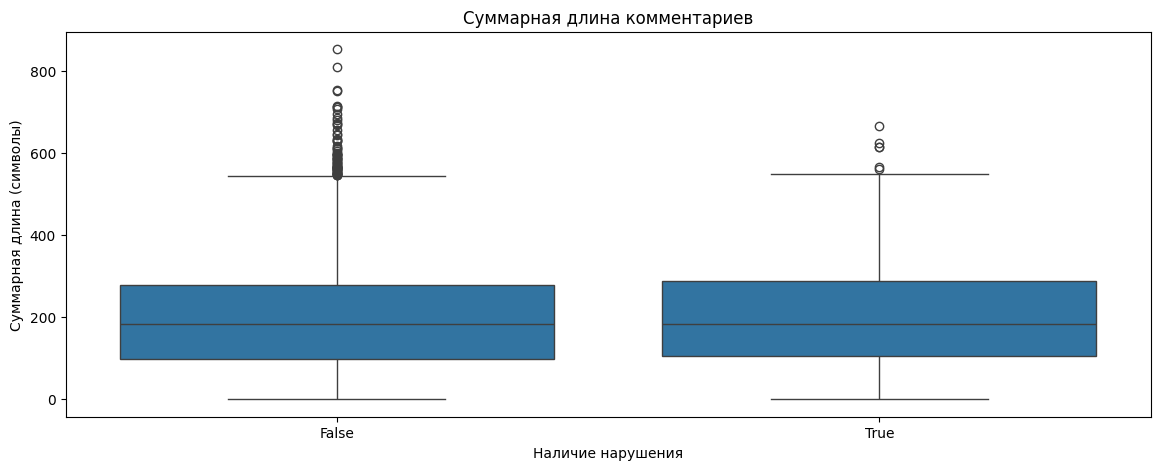

In [38]:
plt.figure(figsize=(14,5))
sns.boxplot(x='has_violation', y='total_comment_length', data=df_comment_stats)
plt.title('Суммарная длина комментариев')
plt.xlabel('Наличие нарушения')
plt.ylabel('Суммарная длина (символы)')
plt.show()

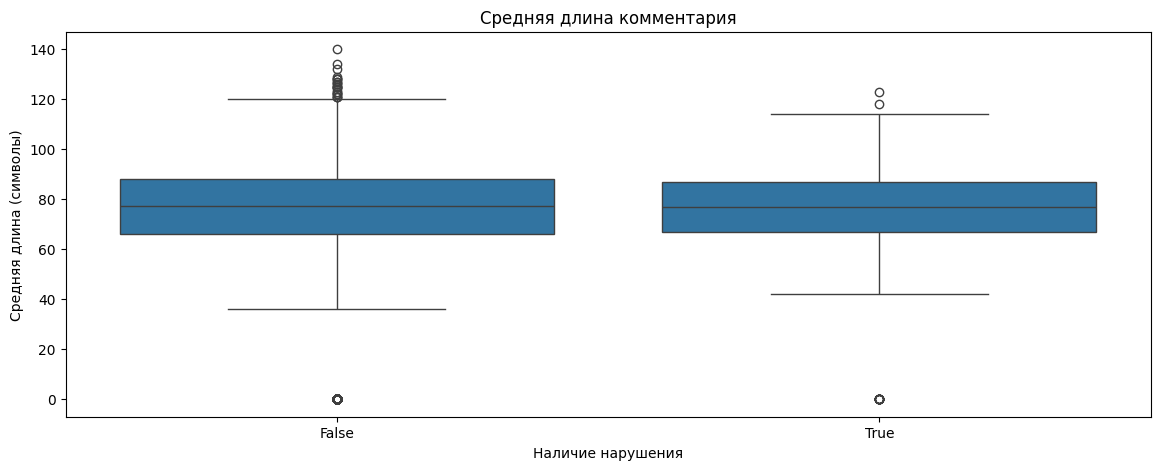

In [39]:
plt.figure(figsize=(14,5))
sns.boxplot(x='has_violation', y='avg_comment_length', data=df_comment_stats)
plt.title('Средняя длина комментария')
plt.xlabel('Наличие нарушения')
plt.ylabel('Средняя длина (символы)')
plt.show()

In [40]:
df_comment_stats.groupby('has_violation')[['total_comment_length', 'avg_comment_length', 'num_comments']].describe()

total_comment_length                                             \
                             count        mean         std  min    25%    50%   
has_violation                                                                   
False                       6164.0  198.250649  128.381056  0.0   99.0  184.0   
True                         273.0  204.743590  132.278562  0.0  106.0  184.0   

                            avg_comment_length             ...               \
                 75%    max              count       mean  ...   75%    max   
has_violation                                              ...                
False          278.0  853.0             6164.0  72.853927  ...  88.0  140.0   
True           287.0  667.0              273.0  74.602191  ...  87.0  123.0   

              num_comments                                                
                     count      mean       std  min  25%  50%  75%   max  
has_violation                                                             
False               6164.0  2.506976  1.572557  0.0  1.0  2.0  3.0  10.0  
True                 273.0  2.608059  1.641670  0.0  1.0  2.0  4.0   9.0  

[2 rows x 24 columns]


**Выводы по реальным данным:Выводы на основании реальных данных - в отличие от синтетики качество данных в ряде показателей не является удовлетворительным, уточнение ряда булевых признаков при их расхождении, точная классификация ролей и обоснованность алгоритмически выевляемых расхождений требует анализа введённого людьми текста.Классификация ряда применяющихся типов не очевидна, часто имеются синонимичные по общему смыслу типы с разными классами в системе. Консультация с доступными экспертами ситуацию не прояснил - типы сложились в ходе особенностей практического применения. В ряде процедур отсутствует однозначная связь между конкретной заявкой и итоговым документом, что требует анализа текста 1-4 заявок.Часто в разных системах для обозначения одного и того же используются разные варинты написания, что усложняет сверку алгоритмами, однако при помощи алгоритмических методов можно значительно сократить колличество анализируемых строк (в конкретном примере ппереписанных в процессе условий получилось снизить колличество случаев с тысяч до около двух сотен)**
